# Gesamtanalyse – ARIMA-Modell Luftdruck Würzburg

**Datenquelle:** `data/cleaned/wuerzburg_klima_tagesdaten_05705_clean_2.csv` – Spalte `PM`
**Ausgabe:** `Plots/` (7 Abbildungen)

**Komplettes ARIMA-Modell** – von den bereinigten Tagesdaten bis zur 10-Tage-Prognose
inklusive Train/Test-Evaluation und 5-Fold-Cross-Validation.

Box-Jenkins-Schritte: Stationaritätstests → Transformation → ACF/PACF →
Modellselektion → Residuendiagnose → t-Statistiken → Prognose → Evaluation.

In [10]:
import warnings
warnings.filterwarnings("ignore")

import os
import matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import stats
import itertools

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"
from pathlib import Path

def _repo_root():
    p = Path().resolve()
    for folder in [p, *p.parents]:
        if (folder / ".git").is_dir():
            return folder
    return p

ROOT     = _repo_root()
CSV_PFAD = ROOT / "data" / "cleaned" / "wuerzburg_klima_tagesdaten_05705_clean_2.csv"
PLOTORDNER = "Plots"
os.makedirs(PLOTORDNER, exist_ok=True)

## 0. DATEN LADEN UND VORVERARBEITEN

In [ ]:
# Daten aus bereinigter CSV laden
df_clean = pd.read_csv(CSV_PFAD, parse_dates=["MESS_DATUM"], index_col="MESS_DATUM")
df_clean = df_clean.sort_index().asfreq("D")
df_clean["PM"] = df_clean["PM"].interpolate(method="time").ffill().bfill()

# Cutoff-Datum: Daten bis einschliesslich 31.12.2025 (Trainings- und Analysezeitraum)
CUTOFF_DATE = pd.Timestamp("2026-01-01")
ts = df_clean.loc[df_clean.index < CUTOFF_DATE, "PM"].rename("PP_TER")  # Luftdruck [hPa]

# Monatsmittel fuer Uebersichtsplot
ts_daily   = ts.copy()
ts_monthly = ts.resample("MS").mean()

print(f"Cutoff-Datum   : {CUTOFF_DATE.date()} (exklusiv)")
print(f"Datensatz      : {ts.index[0].date()} bis {ts.index[-1].date()}")
print(f"Tageswerte     : {len(ts):,}  |  Monatswerte: {len(ts_monthly):,}")
print(f"Mittelwert     : {ts.mean():.2f} hPa  |  Std: {ts.std():.2f} hPa")

## 1. ROHDATEN VISUALISIERUNG

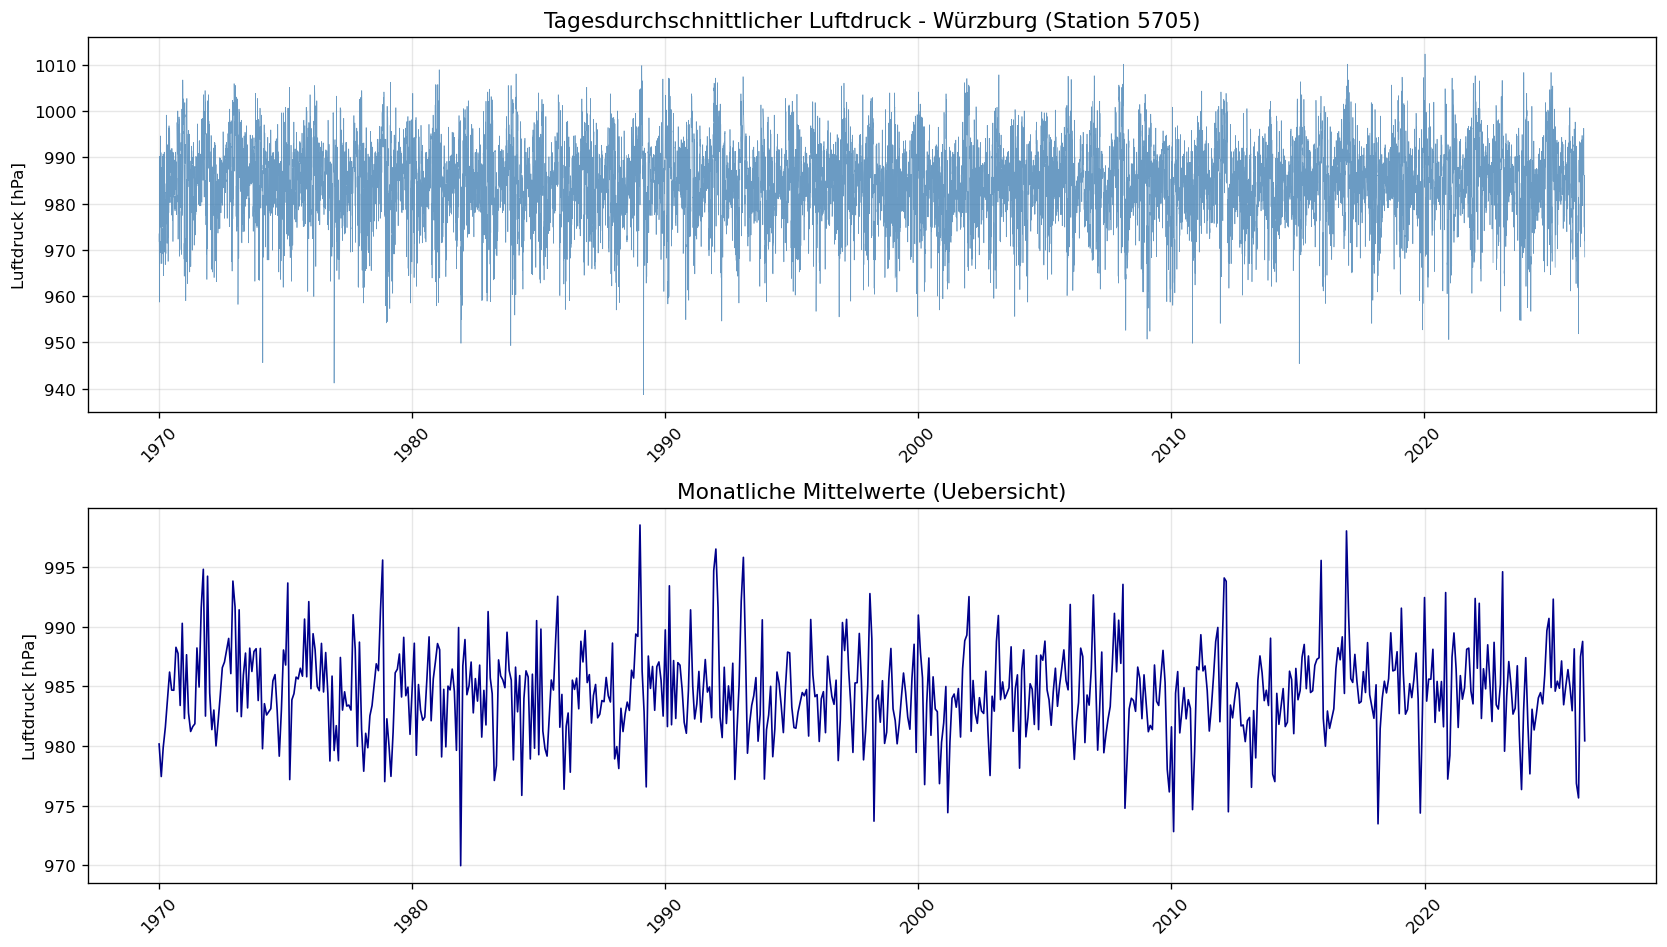


[Abbildung 1 gespeichert: 01_rohdaten.png]


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
axes[0].plot(ts_daily.index, ts_daily.values, lw=0.4, color="steelblue", alpha=0.8)
axes[0].set_title(
    "Tagesdurchschnittlicher Luftdruck - Würzburg (Station 5705)", fontsize=13
)
axes[0].set_ylabel("Luftdruck [hPa]")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].xaxis.set_major_locator(mdates.YearLocator(10))

axes[1].plot(ts_monthly.index, ts_monthly.values, lw=1.0, color="darkblue")
axes[1].set_title(
    "Monatliche Mittelwerte (Uebersicht)", fontsize=13
)
axes[1].set_ylabel("Luftdruck [hPa]")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].xaxis.set_major_locator(mdates.YearLocator(10))

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, "01_rohdaten.png"), bbox_inches="tight")
plt.show()
print("\n[Abbildung 1 gespeichert: 01_rohdaten.png]")

## 2. STATIONARITAETSTESTS (SCHRITT 1: INTEGRATIONSORDNUNG)

In [13]:
print("\n" + "=" * 65)
print("SCHRITT 1: INTEGRATIONSORDNUNG - STATIONARITAETSTESTS")
print("=" * 65)


def adf_test(serie, bezeichnung=""):
    """Augmented Dickey-Fuller Test mit automatischer Lag-Auswahl (AIC)."""
    result = adfuller(serie.dropna(), autolag="AIC")
    print(f"\n  ADF-Test: {bezeichnung}")
    print(f"    Teststatistik : {result[0]:.4f}")
    print(f"    p-Wert        : {result[1]:.4f}")
    print(f"    Lags verwendet: {result[2]}")
    print(
        f"    Krit. Werte   : 1%={result[4]['1%']:.3f}, "
        f"5%={result[4]['5%']:.3f}, 10%={result[4]['10%']:.3f}"
    )
    entscheidung = "STATIONAER" if result[1] < 0.05 else "NICHT STATIONAER"
    print(f"    => Entscheidung (5% Niveau): {entscheidung}")
    return result[1]


def kpss_test(serie, bezeichnung=""):
    """KPSS-Test (H0: Stationaritaet)."""
    result = kpss(serie.dropna(), regression="c", nlags="auto")
    print(f"\n  KPSS-Test: {bezeichnung}")
    print(f"    Teststatistik : {result[0]:.4f}")
    print(f"    p-Wert        : {result[1]:.4f}")
    print(f"    Krit. Werte   : {result[3]}")
    entscheidung = "NICHT STATIONAER" if result[1] < 0.05 else "STATIONAER"
    print(f"    => Entscheidung (5% Niveau): {entscheidung}")
    return result[1]


# Niveau
print("\n--- Niveau der Zeitreihe ---")
p_adf_niveau = adf_test(ts, "Taeglicher Luftdruck (Niveau)")
p_kpss_niveau = kpss_test(ts, "Taeglicher Luftdruck (Niveau)")

# Erste Differenz
ts_diff1 = ts.diff().dropna()
print("\n--- Erste Differenz ---")
p_adf_d1 = adf_test(ts_diff1, "Erste Differenz (d=1)")
p_kpss_d1 = kpss_test(ts_diff1, "Erste Differenz (d=1)")

# Integrationsordnung bestimmen
if p_adf_niveau < 0.05 and p_kpss_niveau >= 0.05:
    d = 0
    print("\n  => Zeitreihe ist im NIVEAU stationaer => d = 0")
elif p_adf_d1 < 0.05 or p_kpss_d1 >= 0.05:
    d = 1
    print("\n  => Zeitreihe wird nach ERSTER DIFFERENZIERUNG stationaer => d = 1")
else:
    d = 1
    print("\n  => d = 1 (konservative Wahl bei gemischten Testergebnissen)")

print(f"\n  Gewaehlte Integrationsordnung: d = {d}")


SCHRITT 1: INTEGRATIONSORDNUNG - STATIONARITAETSTESTS

--- Niveau der Zeitreihe ---

  ADF-Test: Taeglicher Luftdruck (Niveau)
    Teststatistik : -31.0625
    p-Wert        : 0.0000
    Lags verwendet: 12
    Krit. Werte   : 1%=-3.431, 5%=-2.862, 10%=-2.567
    => Entscheidung (5% Niveau): STATIONAER

  KPSS-Test: Taeglicher Luftdruck (Niveau)
    Teststatistik : 0.1179
    p-Wert        : 0.1000
    Krit. Werte   : {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
    => Entscheidung (5% Niveau): STATIONAER

--- Erste Differenz ---

  ADF-Test: Erste Differenz (d=1)
    Teststatistik : -34.9034
    p-Wert        : 0.0000
    Lags verwendet: 46
    Krit. Werte   : 1%=-3.431, 5%=-2.862, 10%=-2.567
    => Entscheidung (5% Niveau): STATIONAER

  KPSS-Test: Erste Differenz (d=1)
    Teststatistik : 0.0550
    p-Wert        : 0.1000
    Krit. Werte   : {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
    => Entscheidung (5% Niveau): STATIONAER

  => Zeitreihe ist im NIVEAU st

## 3. TRANSFORMATION (SCHRITT 2: STATIONARITAET HERSTELLEN)


SCHRITT 2: TRANSFORMATION ZUR STATIONARITAET
  Keine Differenzierung notwendig - Niveau wird verwendet.


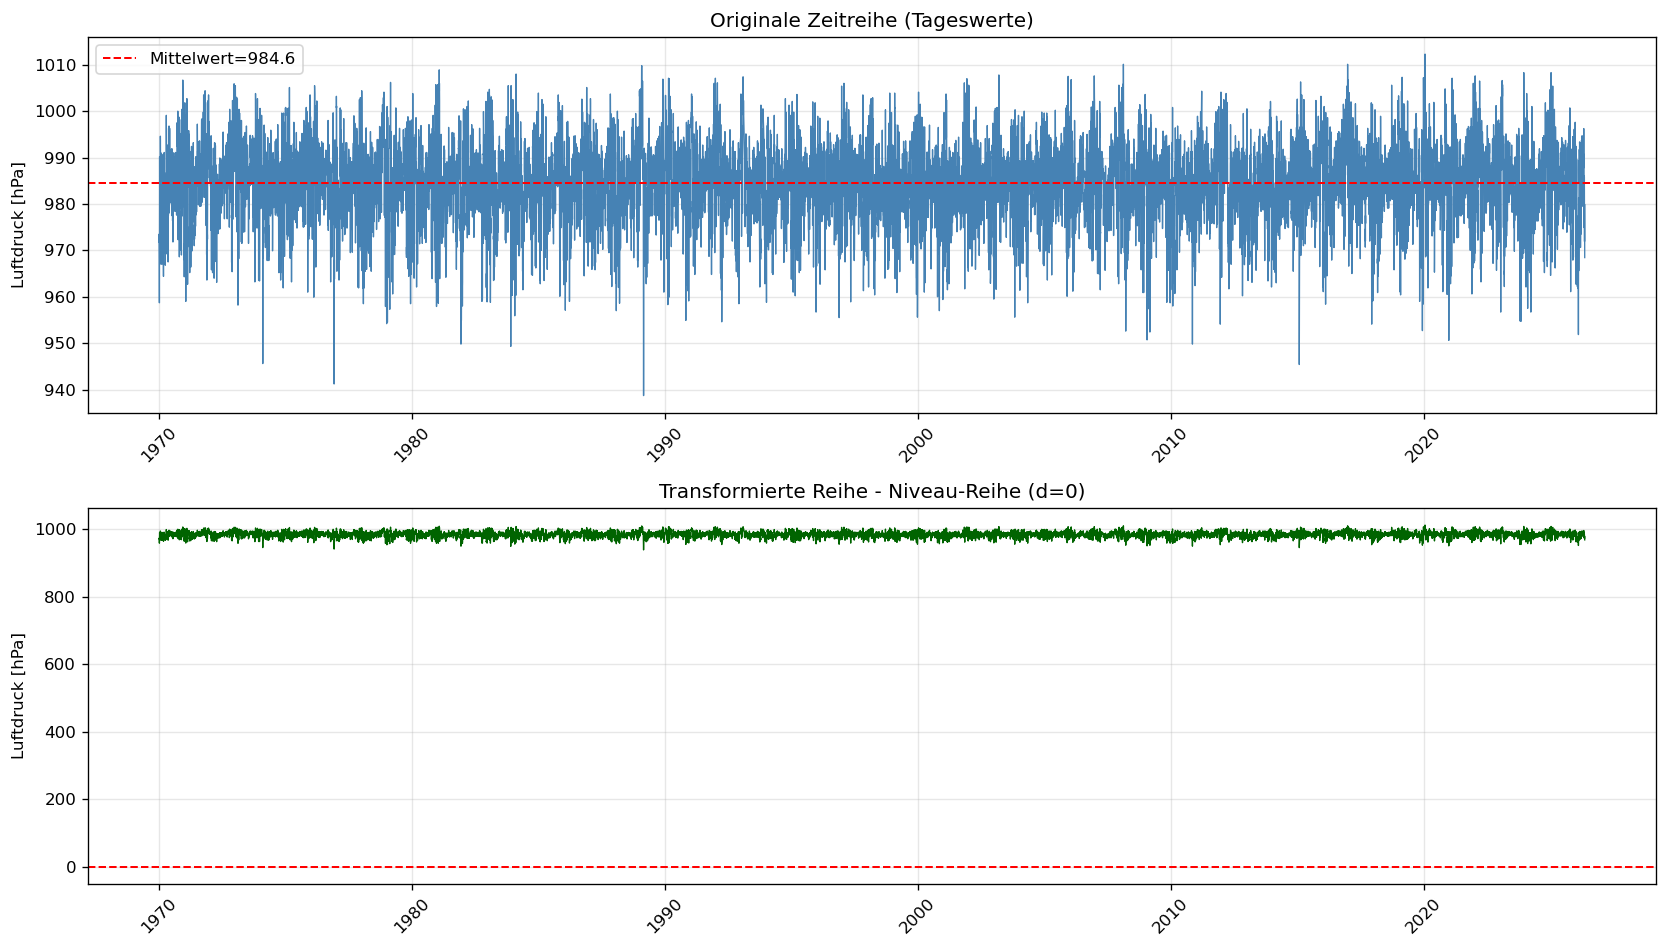


[Abbildung 2 gespeichert: 02_transformation.png]


In [14]:
print("\n" + "=" * 65)
print("SCHRITT 2: TRANSFORMATION ZUR STATIONARITAET")
print("=" * 65)

if d == 0:
    ts_stat = ts.copy()
    print("  Keine Differenzierung notwendig - Niveau wird verwendet.")
else:
    ts_stat = ts.diff(d).dropna()
    print(f"  {d}-fache Differenzierung angewendet.")
    print(f"  Neue Reihe: {len(ts_stat)} Beobachtungen")
    print(f"  Mittelwert: {ts_stat.mean():.4f} hPa  |  Std: {ts_stat.std():.4f} hPa")

# Visualisierung der Transformation
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(ts.index, ts.values, color="steelblue", lw=0.8)
axes[0].set_title("Originale Zeitreihe (Tageswerte)", fontsize=12)
axes[0].set_ylabel("Luftdruck [hPa]")
axes[0].axhline(
    ts.mean(), color="red", ls="--", lw=1.2, label=f"Mittelwert={ts.mean():.1f}"
)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ts_stat.index, ts_stat.values, color="darkgreen", lw=0.8)
titel = "Differenzierte Reihe (d=1)" if d > 0 else "Niveau-Reihe (d=0)"
axes[1].set_title(f"Transformierte Reihe - {titel}", fontsize=12)
axes[1].set_ylabel("Delta Luftdruck [hPa]" if d > 0 else "Luftdruck [hPa]")
axes[1].axhline(0, color="red", ls="--", lw=1.2)
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(10))
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, "02_transformation.png"), bbox_inches="tight")
plt.show()
print("\n[Abbildung 2 gespeichert: 02_transformation.png]")

## 4. ACF UND PACF (SCHRITT 3)


SCHRITT 3: ACF UND PACF DER TRANSFORMIERTEN REIHE


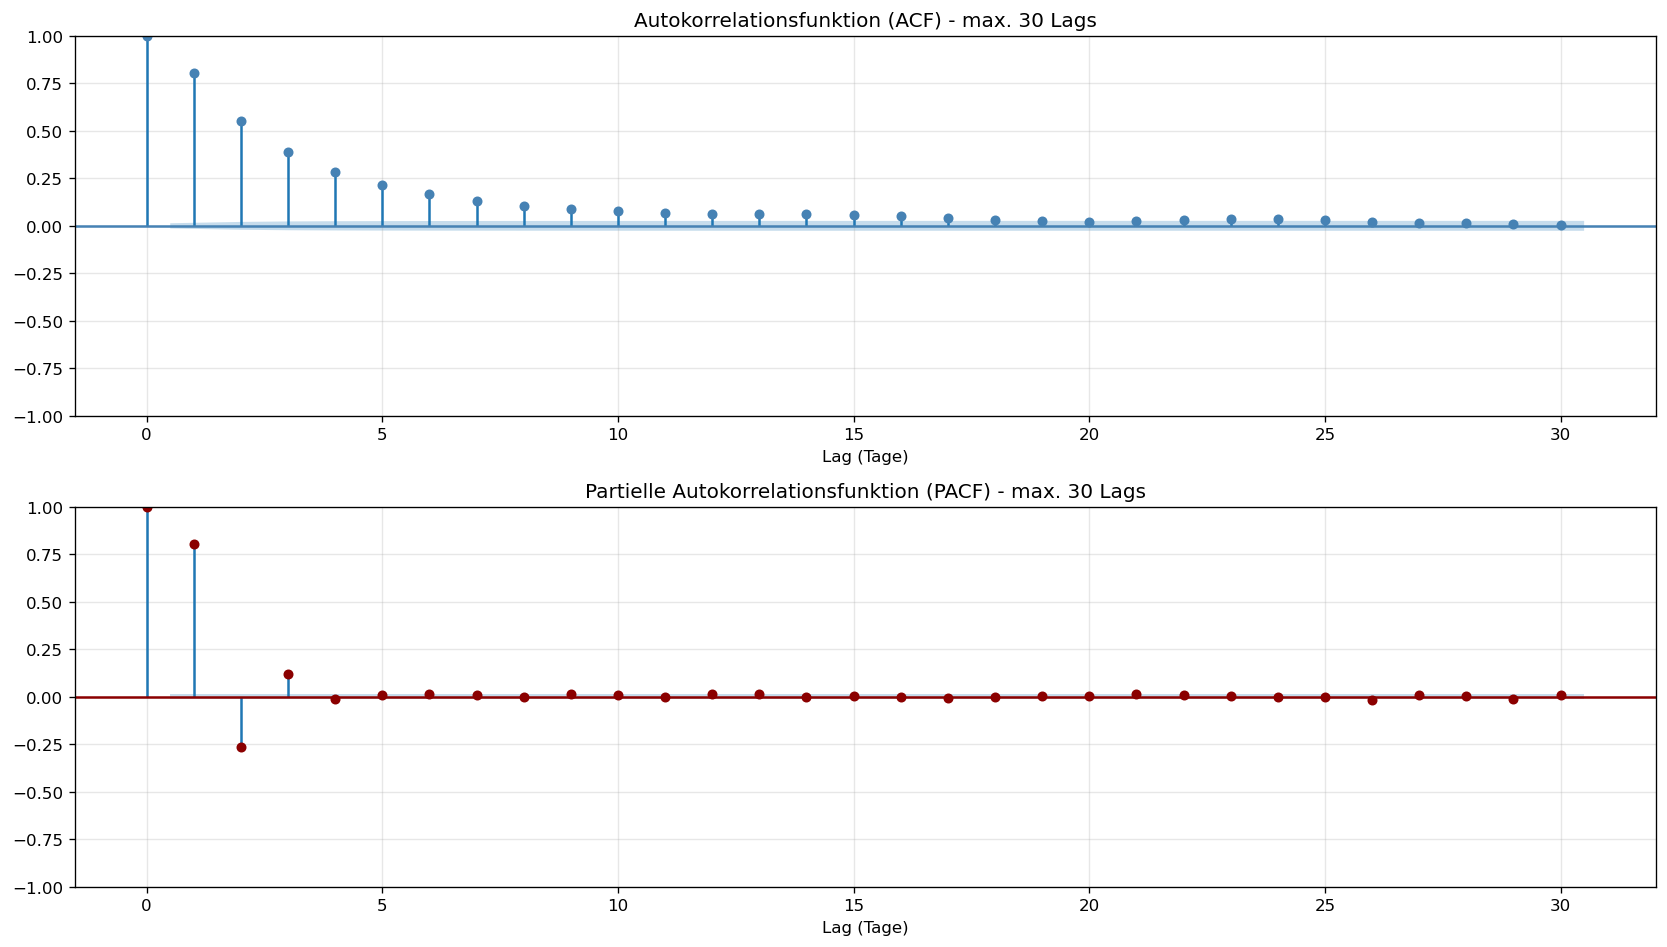


[Abbildung 3 gespeichert: 03_acf_pacf.png]

  Signifikante ACF-Lags  (5%): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
  Signifikante PACF-Lags (5%): [1, 2, 3, 4, 9, 12, 13, 21, 26]

  Interpretation:
  - Abrupter Abfall der PACF nach Lag p => AR(p)-Anteil
  - Abrupter Abfall der ACF nach Lag q  => MA(q)-Anteil
  - Geometrisch abklingende ACF + PACF-Abbruch => AR-Prozess
  - Geometrisch abklingende PACF + ACF-Abbruch => MA-Prozess



In [15]:
print("\n" + "=" * 65)
print("SCHRITT 3: ACF UND PACF DER TRANSFORMIERTEN REIHE")
print("=" * 65)

max_lag = 30
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(ts_stat, lags=max_lag, ax=axes[0], alpha=0.05, color="steelblue")
axes[0].set_title(
    f"Autokorrelationsfunktion (ACF) - max. {max_lag} Lags", fontsize=12
)
axes[0].set_xlabel("Lag (Tage)")
axes[0].grid(True, alpha=0.3)

plot_pacf(ts_stat, lags=max_lag, ax=axes[1], alpha=0.05, color="darkred", method="ywm")
axes[1].set_title(
    f"Partielle Autokorrelationsfunktion (PACF) - max. {max_lag} Lags", fontsize=12
)
axes[1].set_xlabel("Lag (Tage)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, "03_acf_pacf.png"), bbox_inches="tight")
plt.show()
print("\n[Abbildung 3 gespeichert: 03_acf_pacf.png]")

# Signifikante ACF/PACF-Lags ausgeben
acf_werte = acf(ts_stat, nlags=max_lag, alpha=0.05)
pacf_werte = pacf(ts_stat, nlags=max_lag, alpha=0.05, method="ywm")
acf_konf = acf_werte[1]
pacf_konf = pacf_werte[1]

sig_acf = [
    i for i in range(1, max_lag + 1)
    if abs(acf_werte[0][i]) > (acf_konf[i, 1] - acf_werte[0][i])
]
sig_pacf = [
    i for i in range(1, max_lag + 1)
    if abs(pacf_werte[0][i]) > (pacf_konf[i, 1] - pacf_werte[0][i])
]

print(f"\n  Signifikante ACF-Lags  (5%): {sig_acf[:10]}")
print(f"  Signifikante PACF-Lags (5%): {sig_pacf[:10]}")
print(
    "\n  Interpretation:\n"
    "  - Abrupter Abfall der PACF nach Lag p => AR(p)-Anteil\n"
    "  - Abrupter Abfall der ACF nach Lag q  => MA(q)-Anteil\n"
    "  - Geometrisch abklingende ACF + PACF-Abbruch => AR-Prozess\n"
    "  - Geometrisch abklingende PACF + ACF-Abbruch => MA-Prozess\n"
)

## 5. MODELLSELEKTION (SCHRITT 4)

In [16]:
print("\n" + "=" * 65)
print("SCHRITT 4: MODELLSELEKTION - ARIMA(p,d,q)")
print("=" * 65)

p_werte = range(0, 4)
q_werte = range(0, 4)
ergebnisse = []

print(f"\n  Schaetze ARIMA(p,{d},q) fuer p,q in {{0,1,2,3}} ...")

for p, q in itertools.product(p_werte, q_werte):
    if p == 0 and q == 0:
        continue
    try:
        modell = ARIMA(ts, order=(p, d, q))
        fit = modell.fit()
        ergebnisse.append({
            "p": p, "q": q,
            "AIC": round(fit.aic, 2),
            "BIC": round(fit.bic, 2),
            "LogLik": round(fit.llf, 2),
        })
    except Exception:
        pass

ergebnis_df = pd.DataFrame(ergebnisse).sort_values("AIC")
print("\n  Modellvergleich (sortiert nach AIC):")
print(ergebnis_df.to_string(index=False))

bestes_modell_info = ergebnis_df.iloc[0]
p_best = int(bestes_modell_info["p"])
q_best = int(bestes_modell_info["q"])

# Auch nach BIC bestes Modell
bestes_bic = ergebnis_df.sort_values("BIC").iloc[0]
p_bic = int(bestes_bic["p"])
q_bic = int(bestes_bic["q"])

print(f"\n  Bestes Modell nach AIC: ARIMA({p_best},{d},{q_best})  AIC={bestes_modell_info['AIC']}")
print(f"  Bestes Modell nach BIC: ARIMA({p_bic},{d},{q_bic})   BIC={bestes_bic['BIC']}")

# Wenn AIC und BIC abweichen, nehmen wir AIC
p_final, d_final, q_final = p_best, d, q_best
print(f"\n  => Gewaaehltes Modell: ARIMA({p_final},{d_final},{q_final}) [nach AIC]")


SCHRITT 4: MODELLSELEKTION - ARIMA(p,d,q)

  Schaetze ARIMA(p,0,q) fuer p,q in {0,1,2,3} ...

  Modellvergleich (sortiert nach AIC):
 p  q       AIC       BIC    LogLik
 3  3 122154.18 122217.64 -61069.09
 2  3 122155.26 122210.79 -61070.63
 3  2 122156.16 122211.69 -61071.08
 2  2 122158.20 122205.79 -61073.10
 1  3 122161.88 122209.48 -61074.94
 3  1 122162.01 122209.60 -61075.00
 3  0 122164.21 122203.87 -61077.10
 1  1 122182.61 122214.34 -61087.31
 1  2 122184.38 122224.05 -61087.19
 2  1 122184.44 122224.10 -61087.22
 2  0 122472.16 122503.89 -61232.08
 0  3 123234.42 123274.08 -61612.21
 1  0 123966.26 123990.05 -61980.13
 0  2 124620.34 124652.07 -62306.17
 0  1 129601.35 129625.15 -64797.67

  Bestes Modell nach AIC: ARIMA(3,0,3)  AIC=122154.18
  Bestes Modell nach BIC: ARIMA(3,0,0)   BIC=122203.87

  => Gewaaehltes Modell: ARIMA(3,0,3) [nach AIC]


## 6. FINALES MODELL SCHAETZEN

In [17]:
print("\n" + "=" * 65)
print(f"SCHRITT 5 & 6: MODELLSCHAETZUNG ARIMA({p_final},{d_final},{q_final})")
print("=" * 65)

modell_final = ARIMA(ts, order=(p_final, d_final, q_final))
fit_final = modell_final.fit()
print(fit_final.summary())


SCHRITT 5 & 6: MODELLSCHAETZUNG ARIMA(3,0,3)
                               SARIMAX Results                                
Dep. Variable:                 PP_TER   No. Observations:                20588
Model:                 ARIMA(3, 0, 3)   Log Likelihood              -61069.089
Date:                Sat, 16 May 2026   AIC                         122154.178
Time:                        11:22:10   BIC                         122217.638
Sample:                    01-01-1970   HQIC                        122174.911
                         - 05-14-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        984.5603      0.176   5602.120      0.000     984.216     984.905
ar.L1          1.1116      0.224      4.964      0.000       0.673       1.550
ar.L2 

## 7. T-STATISTIKEN DER KOEFFIZIENTEN (SCHRITT 6)

In [18]:
print("\n" + "=" * 65)
print("SCHRITT 6: T-STATISTIKEN DER KOEFFIZIENTEN")
print("=" * 65)

params = fit_final.params
stderr = fit_final.bse
tstat = fit_final.tvalues
pvalues = fit_final.pvalues

header = (
    f"\n  {'Koeffizient':<18} {'Schaetzer':>10} {'Std.Fehler':>12} "
    f"{'t-Statistik':>12} {'p-Wert':>10} {'Signif.':>8}"
)
print(header)
print("  " + "-" * 75)
for name in params.index:
    sig = (
        "***" if pvalues[name] < 0.01
        else "**" if pvalues[name] < 0.05
        else "*" if pvalues[name] < 0.10
        else ""
    )
    print(
        f"  {name:<18} {params[name]:>10.4f} {stderr[name]:>12.4f} "
        f"{tstat[name]:>12.4f} {pvalues[name]:>10.4f} {sig:>8}"
    )

print("\n  Signifikanzniveaus: *** p<0.01  ** p<0.05  * p<0.10")
print(
    "\n  Interpretation:\n"
    "  - t-Statistik = Schaetzer / Standardfehler\n"
    "  - |t| > 1.96 => signifikant auf 5%-Niveau (ca. N(0,1) bei grossem n)\n"
    "  - p-Wert < 0.05 => Koeffizient signifikant von Null verschieden\n"
)


SCHRITT 6: T-STATISTIKEN DER KOEFFIZIENTEN

  Koeffizient         Schaetzer   Std.Fehler  t-Statistik     p-Wert  Signif.
  ---------------------------------------------------------------------------
  const                984.5603       0.1757    5602.1199     0.0000      ***
  ar.L1                  1.1116       0.2239       4.9636     0.0000      ***
  ar.L2                  0.0787       0.3586       0.2194     0.8264         
  ar.L3                 -0.2365       0.1412      -1.6748     0.0940        *
  ma.L1                 -0.0614       0.2234      -0.2749     0.7834         
  ma.L2                 -0.5368       0.1299      -4.1313     0.0000      ***
  ma.L3                 -0.1670       0.0769      -2.1724     0.0298       **
  sigma2                22.0771       0.1631     135.3732     0.0000      ***

  Signifikanzniveaus: *** p<0.01  ** p<0.05  * p<0.10

  Interpretation:
  - t-Statistik = Schaetzer / Standardfehler
  - |t| > 1.96 => signifikant auf 5%-Niveau (ca. N(0,1) 

## 8. RESIDUENANALYSE (SCHRITT 5)


SCHRITT 5: RESIDUENANALYSE UND MODELLDIAGNOSE


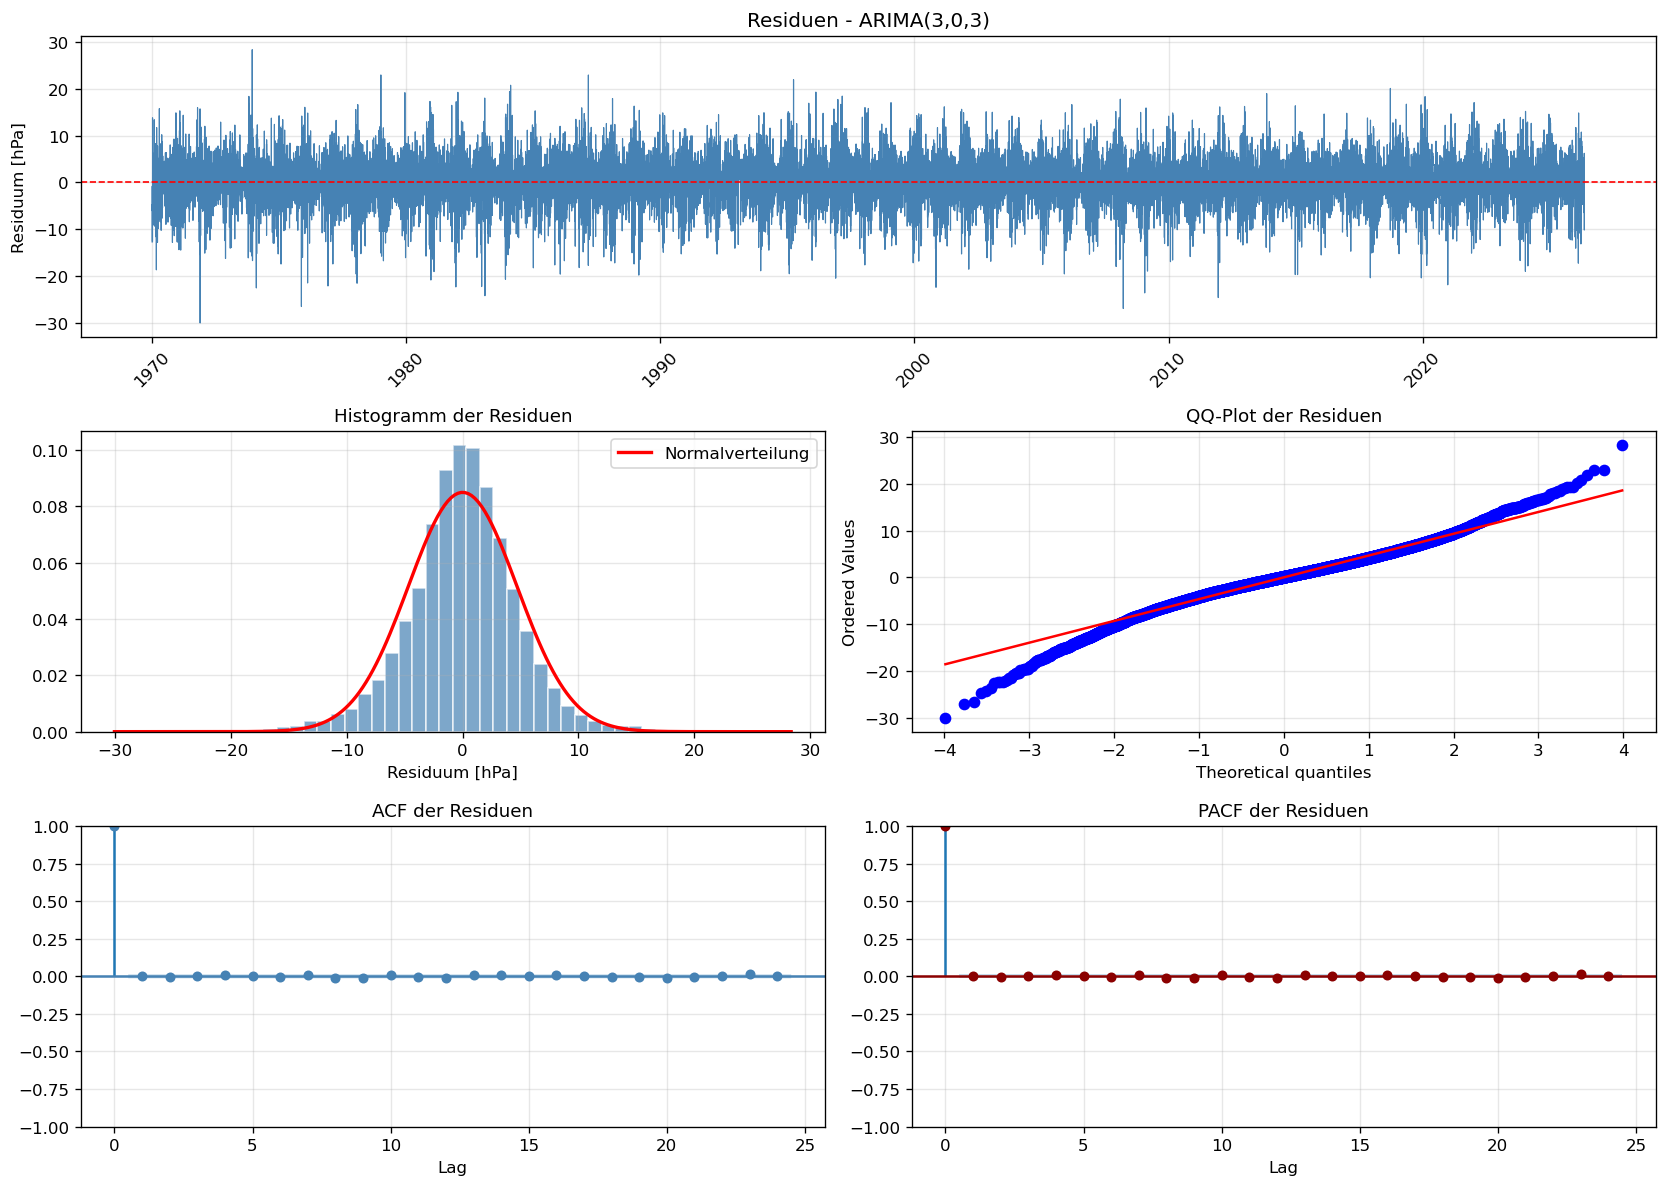


[Abbildung 4 gespeichert: 04_residuenanalyse.png]

  --- Statistische Tests auf Residuen ---

  Ljung-Box-Test (H0: keine Autokorrelation):
    Lag 10: Q=8.304, p=0.5992  => H0 nicht abgelehnt (ok)
    Lag 20: Q=16.968, p=0.6550  => H0 nicht abgelehnt (ok)
    Lag 30: Q=33.348, p=0.3076  => H0 nicht abgelehnt (ok)

  Jarque-Bera-Test (H0: Normalverteilung):
    Statistik=2798.622, p=0.0000  => H0 ABGELEHNT (!)

  ADF-Test auf Residuen (H0: Einheitswurzel):
    Statistik=-143.5787, p=0.0000  => Stationaer (ok)


In [19]:
print("\n" + "=" * 65)
print("SCHRITT 5: RESIDUENANALYSE UND MODELLDIAGNOSE")
print("=" * 65)

residuen = fit_final.resid

fig = plt.figure(figsize=(14, 10))
gs = GridSpec(3, 2, figure=fig)

# Residuen ueber Zeit
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(residuen.index, residuen.values, lw=0.7, color="steelblue")
ax1.axhline(0, color="red", ls="--", lw=1)
ax1.set_title(f"Residuen - ARIMA({p_final},{d_final},{q_final})", fontsize=12)
ax1.set_ylabel("Residuum [hPa]")
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.xaxis.set_major_locator(mdates.YearLocator(10))
ax1.tick_params(axis="x", rotation=45)

# Histogramm der Residuen
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(
    residuen, bins=50, color="steelblue", edgecolor="white", density=True, alpha=0.7
)
x_norm = np.linspace(residuen.min(), residuen.max(), 200)
ax2.plot(
    x_norm,
    stats.norm.pdf(x_norm, residuen.mean(), residuen.std()),
    "r-", lw=2, label="Normalverteilung"
)
ax2.set_title("Histogramm der Residuen", fontsize=11)
ax2.set_xlabel("Residuum [hPa]")
ax2.legend()
ax2.grid(True, alpha=0.3)

# QQ-Plot
ax3 = fig.add_subplot(gs[1, 1])
stats.probplot(residuen, dist="norm", plot=ax3)
ax3.set_title("QQ-Plot der Residuen", fontsize=11)
ax3.grid(True, alpha=0.3)

# ACF der Residuen
ax4 = fig.add_subplot(gs[2, 0])
plot_acf(residuen, lags=24, ax=ax4, alpha=0.05, color="steelblue")
ax4.set_title("ACF der Residuen", fontsize=11)
ax4.set_xlabel("Lag")
ax4.grid(True, alpha=0.3)

# PACF der Residuen
ax5 = fig.add_subplot(gs[2, 1])
plot_pacf(residuen, lags=24, ax=ax5, alpha=0.05, color="darkred", method="ywm")
ax5.set_title("PACF der Residuen", fontsize=11)
ax5.set_xlabel("Lag")
ax5.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, "04_residuenanalyse.png"), bbox_inches="tight")
plt.show()
print("\n[Abbildung 4 gespeichert: 04_residuenanalyse.png]")

# Statistische Tests auf Residuen
print("\n  --- Statistische Tests auf Residuen ---")

# Ljung-Box-Test (keine Autokorrelation in Residuen)
lb_result = acorr_ljungbox(residuen, lags=[10, 20, 30], return_df=True)
print("\n  Ljung-Box-Test (H0: keine Autokorrelation):")
for lag in [10, 20, 30]:
    row = lb_result.loc[lag]
    entscheid = "nicht abgelehnt (ok)" if row["lb_pvalue"] > 0.05 else "ABGELEHNT (!)"
    print(
        f"    Lag {lag:2d}: Q={row['lb_stat']:.3f}, "
        f"p={row['lb_pvalue']:.4f}  => H0 {entscheid}"
    )

# Normalverteilungstest
jb_stat, jb_p = stats.jarque_bera(residuen)
jb_entscheid = "nicht abgelehnt (ok)" if jb_p > 0.05 else "ABGELEHNT (!)"
print(f"\n  Jarque-Bera-Test (H0: Normalverteilung):")
print(f"    Statistik={jb_stat:.3f}, p={jb_p:.4f}  => H0 {jb_entscheid}")

# ADF auf Residuen
print("\n  ADF-Test auf Residuen (H0: Einheitswurzel):")
adf_res = adfuller(residuen, autolag="AIC")
adf_entscheid = "Stationaer (ok)" if adf_res[1] < 0.05 else "Nicht stationaer (!)"
print(f"    Statistik={adf_res[0]:.4f}, p={adf_res[1]:.4f}  => {adf_entscheid}")

## 9. PROGNOSE (SCHRITT 7)


SCHRITT 7: PROGNOSE DER NAECHSTEN 10 TAGE

  10-Tage-Prognose ab 15.05.2026:

  Datum                  Prognose   95%-KI untere    95%-KI obere
  ---------------------------------------------------------------
  15.05.2026               971.62          962.41          980.83
  16.05.2026               975.87          962.51          989.22
  17.05.2026               978.53          963.67          993.40
  18.05.2026               980.23          964.76          995.71
  19.05.2026               981.33          965.57          997.10
  20.05.2026               982.06          966.15          997.97
  21.05.2026               982.55          966.56          998.54
  22.05.2026               982.89          966.85          998.93
  23.05.2026               983.14          967.07          999.21
  24.05.2026               983.32          967.23          999.41


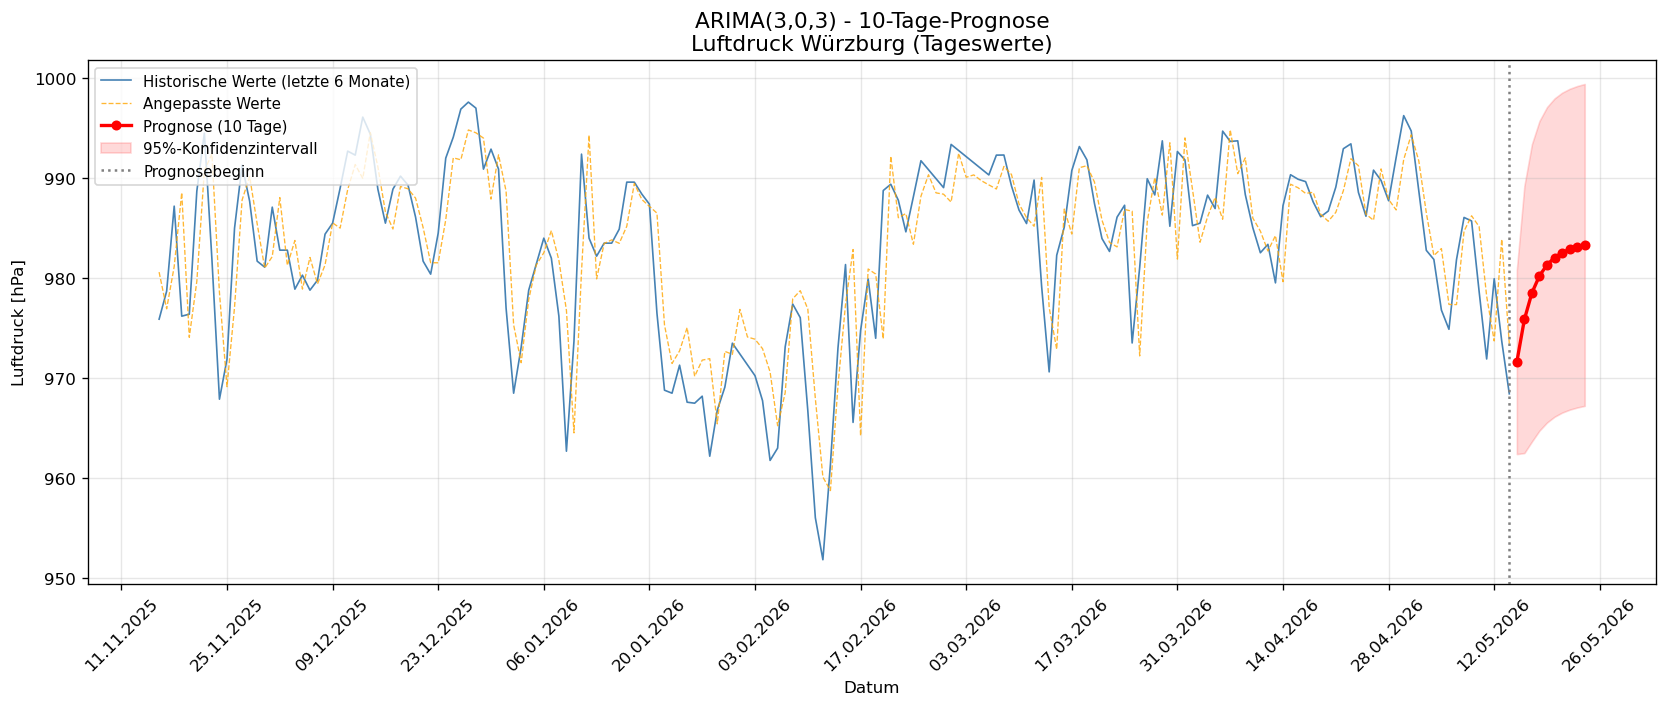


[Abbildung 5 gespeichert: 05_prognose.png]


In [20]:
print("\n" + "=" * 65)
print("SCHRITT 7: PROGNOSE DER NAECHSTEN 10 TAGE")
print("=" * 65)

n_prognose = 10
prognose = fit_final.get_forecast(steps=n_prognose)
prog_mittel = prognose.predicted_mean
prog_ki = prognose.conf_int(alpha=0.05)

# Prognosedaten ausgeben
print(f"\n  10-Tage-Prognose ab {prog_mittel.index[0].strftime('%d.%m.%Y')}:")
print(
    f"\n  {'Datum':<18} {'Prognose':>12} "
    f"{'95%-KI untere':>15} {'95%-KI obere':>15}"
)
print("  " + "-" * 63)
for datum, prog, ki_u, ki_o in zip(
    prog_mittel.index,
    prog_mittel.values,
    prog_ki.iloc[:, 0].values,
    prog_ki.iloc[:, 1].values,
):
    print(
        f"  {datum.strftime('%d.%m.%Y'):<18} {prog:>12.2f} "
        f"{ki_u:>15.2f} {ki_o:>15.2f}"
    )

# Visualisierung der Prognose
n_historisch = 180  # letzte 6 Monate fuer Plot
ts_plot = ts.iloc[-n_historisch:]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    ts_plot.index, ts_plot.values,
    color="steelblue", lw=1.0,
    label="Historische Werte (letzte 6 Monate)"
)

# Historische Fitted Values (letzter Abschnitt)
fitted = fit_final.fittedvalues.iloc[-n_historisch:]
ax.plot(
    fitted.index, fitted.values,
    color="orange", lw=0.8, ls="--", alpha=0.8,
    label="Angepasste Werte"
)

ax.plot(
    prog_mittel.index, prog_mittel.values,
    color="red", lw=2, marker="o", markersize=5,
    label="Prognose (10 Tage)"
)
ax.fill_between(
    prog_ki.index,
    prog_ki.iloc[:, 0],
    prog_ki.iloc[:, 1],
    color="red", alpha=0.15,
    label="95%-Konfidenzintervall"
)

ax.axvline(ts.index[-1], color="gray", ls=":", lw=1.5, label="Prognosebeginn")
ax.set_title(
    f"ARIMA({p_final},{d_final},{q_final}) - 10-Tage-Prognose\n"
    f"Luftdruck Würzburg (Tageswerte)",
    fontsize=13,
)
ax.set_ylabel("Luftdruck [hPa]")
ax.set_xlabel("Datum")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m.%Y"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, "05_prognose.png"), bbox_inches="tight")
plt.show()
print("\n[Abbildung 5 gespeichert: 05_prognose.png]")

## ABSCHNITT 8: TRAIN/TEST-SPLIT (70/30) & MODELL-EVALUATION


ABSCHNITT 8: MODELL-EVALUATION – TRAIN/TEST-SPLIT (70/30)

  Trainingsdaten : 14,411 Tage  (1970-01-01 – 2009-06-15)
  Testdaten      : 6,177 Tage  (2009-06-16 – 2026-05-14)

  Schaetze ARIMA(3,0,3) auf Trainingsdaten ...

  Test-Set-Metriken (Multi-Step-Prognose ueber 6,177 Tage):
  Metrik            Wert  Einheit
  ------------------------------------
  MSE            66.2039  hPa^2
  RMSE            8.1366  hPa
  MAE             6.2546  hPa
  MAPE            0.6359  %


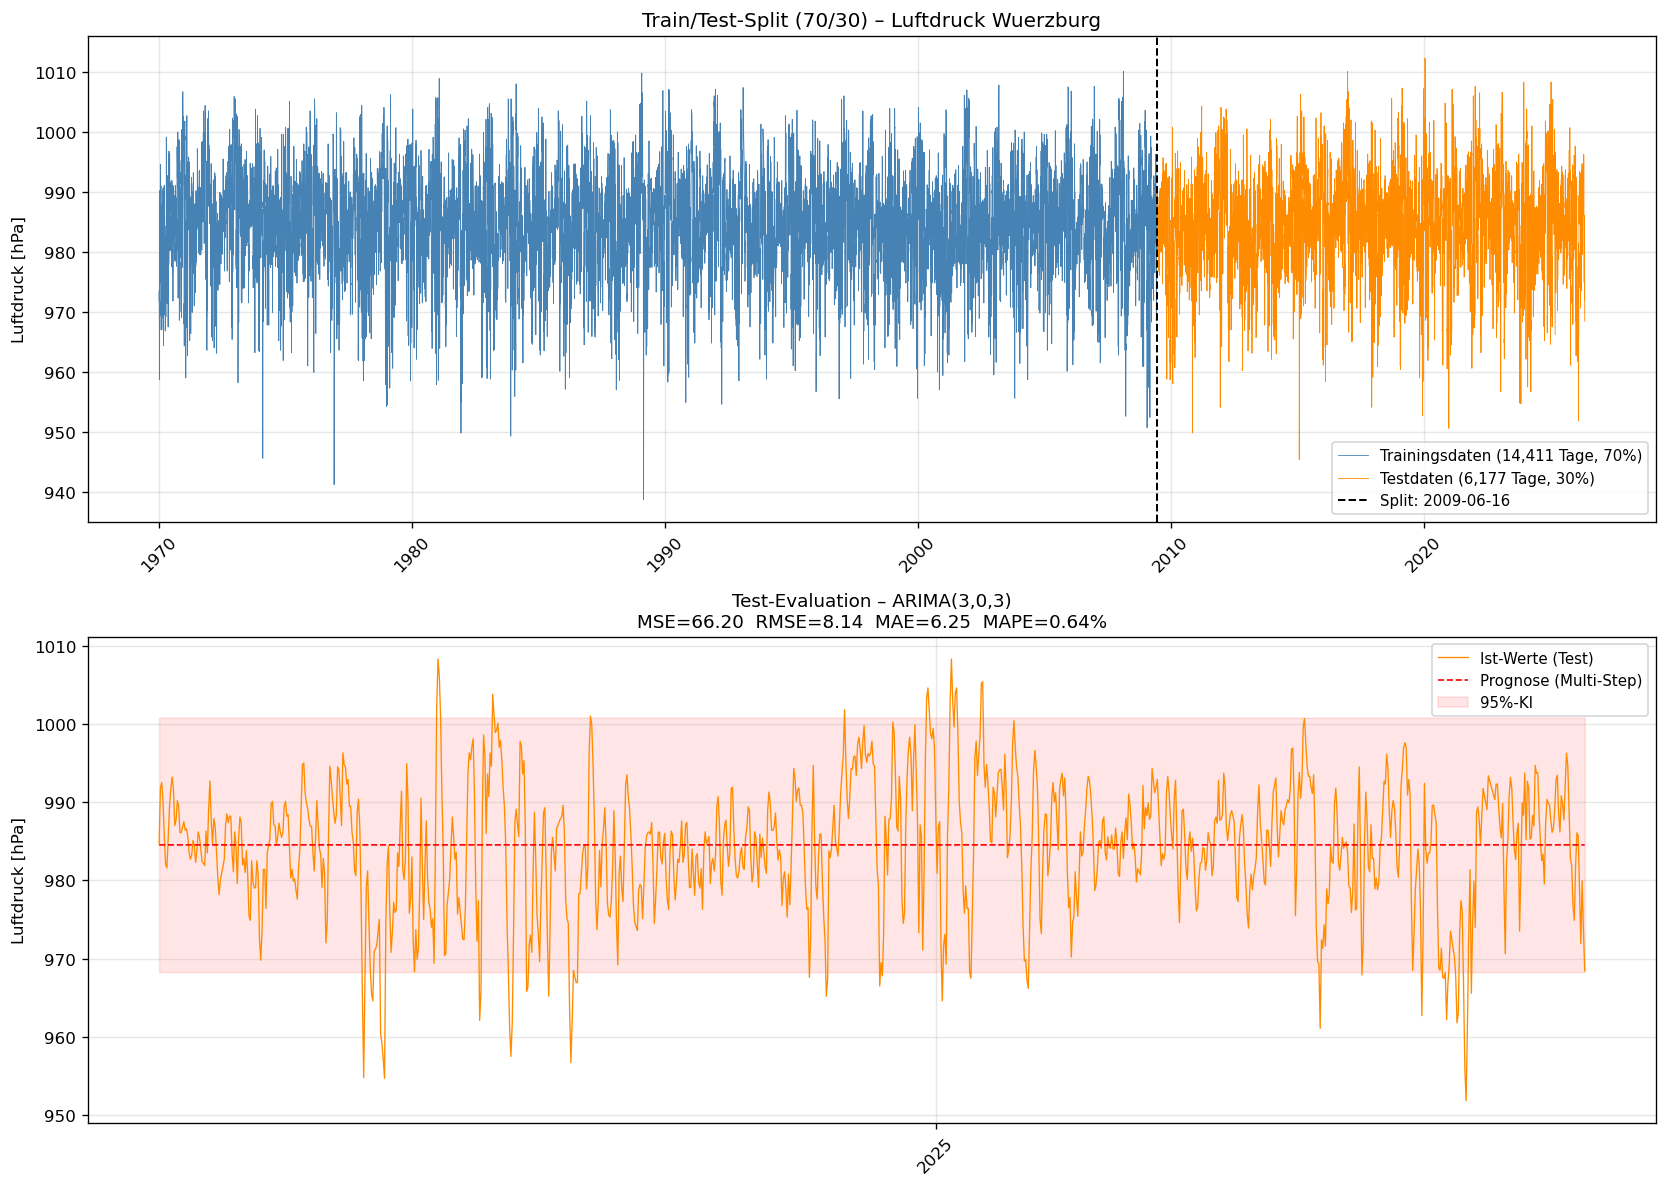


[Abbildung 6 gespeichert: 06_train_test_evaluation.png]


In [21]:
print("\n" + "=" * 65)
print("ABSCHNITT 8: MODELL-EVALUATION – TRAIN/TEST-SPLIT (70/30)")
print("=" * 65)

n_train   = int(len(ts) * 0.70)
ts_train  = ts.iloc[:n_train]
ts_test   = ts.iloc[n_train:]
print(f"\n  Trainingsdaten : {len(ts_train):,} Tage  "
      f"({ts_train.index[0].date()} – {ts_train.index[-1].date()})")
print(f"  Testdaten      : {len(ts_test):,} Tage  "
      f"({ts_test.index[0].date()} – {ts_test.index[-1].date()})")

print(f"\n  Schaetze ARIMA({p_final},{d_final},{q_final}) auf Trainingsdaten ...")
fit_train = ARIMA(ts_train, order=(p_final, d_final, q_final)).fit()
fc_obj    = fit_train.get_forecast(steps=len(ts_test))
fc_werte  = fc_obj.predicted_mean
fc_ki     = fc_obj.conf_int(alpha=0.05)
fc_werte.index = ts_test.index
fc_ki.index    = ts_test.index

mse_test  = mean_squared_error(ts_test, fc_werte)
rmse_test = np.sqrt(mse_test)
mae_test  = mean_absolute_error(ts_test, fc_werte)
mape_test = np.mean(np.abs((ts_test.values - fc_werte.values) / ts_test.values)) * 100

print(f"\n  Test-Set-Metriken (Multi-Step-Prognose ueber {len(ts_test):,} Tage):")
print(f"  {'Metrik':<8}  {'Wert':>12}  Einheit")
print("  " + "-" * 36)
print(f"  {'MSE':<8}  {mse_test:>12.4f}  hPa^2")
print(f"  {'RMSE':<8}  {rmse_test:>12.4f}  hPa")
print(f"  {'MAE':<8}  {mae_test:>12.4f}  hPa")
print(f"  {'MAPE':<8}  {mape_test:>12.4f}  %")

# Plot: Train/Test-Split + Evaluation
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Abb. 6a: gesamter Split
axes[0].plot(ts_train.index, ts_train.values, color="steelblue", lw=0.5,
             label=f"Trainingsdaten ({len(ts_train):,} Tage, 70%)")
axes[0].plot(ts_test.index,  ts_test.values,  color="darkorange", lw=0.5,
             label=f"Testdaten ({len(ts_test):,} Tage, 30%)")
axes[0].axvline(ts_test.index[0], color="black", ls="--", lw=1.2,
                label=f"Split: {ts_test.index[0].date()}")
axes[0].set_title("Train/Test-Split (70/30) – Luftdruck Wuerzburg", fontsize=12)
axes[0].set_ylabel("Luftdruck [hPa]")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].xaxis.set_major_locator(mdates.YearLocator(10))
axes[0].tick_params(axis="x", rotation=45)

# Abb. 6b: Prognose vs. Ist auf Testdaten (letzte 3 Jahre des Tests)
n_zoom = min(1095, len(ts_test))
axes[1].plot(ts_test.iloc[-n_zoom:].index, ts_test.iloc[-n_zoom:].values,
             color="darkorange", lw=0.8, label="Ist-Werte (Test)")
axes[1].plot(fc_werte.iloc[-n_zoom:].index, fc_werte.iloc[-n_zoom:].values,
             color="red", lw=1.0, ls="--", label="Prognose (Multi-Step)")
axes[1].fill_between(fc_ki.iloc[-n_zoom:].index,
                     fc_ki.iloc[-n_zoom:, 0], fc_ki.iloc[-n_zoom:, 1],
                     color="red", alpha=0.10, label="95%-KI")
axes[1].set_title(
    f"Test-Evaluation – ARIMA({p_final},{d_final},{q_final})\n"
    f"MSE={mse_test:.2f}  RMSE={rmse_test:.2f}  MAE={mae_test:.2f}  MAPE={mape_test:.2f}%",
    fontsize=11
)
axes[1].set_ylabel("Luftdruck [hPa]")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].xaxis.set_major_locator(mdates.YearLocator(5))
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, "06_train_test_evaluation.png"), bbox_inches="tight")
plt.show()
print("\n[Abbildung 6 gespeichert: 06_train_test_evaluation.png]")

## ABSCHNITT 9: TIME-SERIES-CROSS-VALIDATION (5-Fold)


ABSCHNITT 9: TIME-SERIES-CROSS-VALIDATION (5-Fold)

  CV-Pool    : letzte 730 Tage der Trainingsdaten
  Fold-Groesse: 30 Tage | Anzahl Folds: 5

  Fold    Train-Obs        MSE       RMSE        MAE    MAPE(%)
  ------------------------------------------------------------
  1             580   270.2252    16.4385    13.6732     1.4133
  2             610   108.2678    10.4052     7.6544     0.7818
  3             640    60.8396     7.8000     6.2220     0.6366
  4             670    32.8456     5.7311     4.6892     0.4768
  5             700    34.3504     5.8609     4.5595     0.4634
  ------------------------------------------------------------
  Mittel              101.3057     9.2471     7.3597     0.7544
  Std.                 99.2340     4.4435     3.7488     0.3907


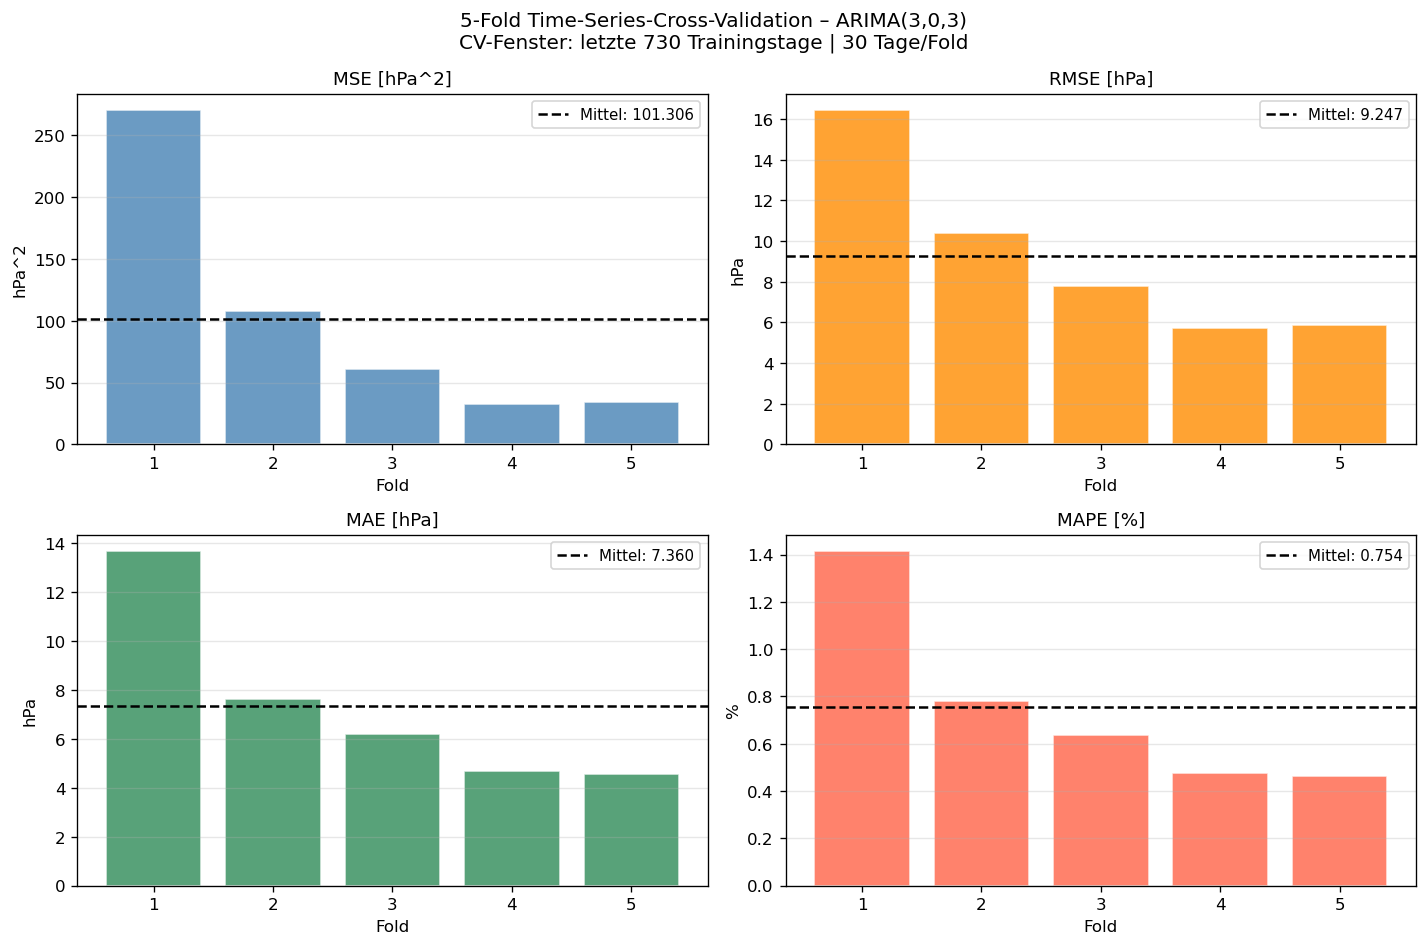


[Abbildung 7 gespeichert: 07_cv_metriken.png]


In [22]:
print("\n" + "=" * 65)
print("ABSCHNITT 9: TIME-SERIES-CROSS-VALIDATION (5-Fold)")
print("=" * 65)

CV_FENSTER  = 730
CV_TESTSIZE = 30
N_SPLITS    = 5
ts_cv = ts_train.iloc[-CV_FENSTER:]
tscv  = TimeSeriesSplit(n_splits=N_SPLITS, test_size=CV_TESTSIZE)

print(f"\n  CV-Pool    : letzte {CV_FENSTER} Tage der Trainingsdaten")
print(f"  Fold-Groesse: {CV_TESTSIZE} Tage | Anzahl Folds: {N_SPLITS}\n")
print(f"  {'Fold':<6} {'Train-Obs':>10} {'MSE':>10} {'RMSE':>10} {'MAE':>10} {'MAPE(%)':>10}")
print("  " + "-" * 60)

fold_metriken = []
for fold, (idx_tr, idx_te) in enumerate(tscv.split(ts_cv)):
    cv_tr = ts_cv.iloc[idx_tr]
    cv_te = ts_cv.iloc[idx_te]
    fc_cv = ARIMA(cv_tr, order=(p_final, d_final, q_final)).fit() \
                 .get_forecast(steps=len(cv_te)).predicted_mean
    fc_cv.index = cv_te.index
    m = {
        "Fold": fold + 1,
        "MSE" : mean_squared_error(cv_te, fc_cv),
        "RMSE": np.sqrt(mean_squared_error(cv_te, fc_cv)),
        "MAE" : mean_absolute_error(cv_te, fc_cv),
        "MAPE": np.mean(np.abs((cv_te.values - fc_cv.values) / cv_te.values)) * 100,
    }
    fold_metriken.append(m)
    print(f"  {m['Fold']:<6} {len(cv_tr):>10,} {m['MSE']:>10.4f} "
          f"{m['RMSE']:>10.4f} {m['MAE']:>10.4f} {m['MAPE']:>10.4f}")

cv_df = pd.DataFrame(fold_metriken)
print("  " + "-" * 60)
print(f"  {'Mittel':<17} {cv_df['MSE'].mean():>10.4f} {cv_df['RMSE'].mean():>10.4f} "
      f"{cv_df['MAE'].mean():>10.4f} {cv_df['MAPE'].mean():>10.4f}")
print(f"  {'Std.':<17} {cv_df['MSE'].std():>10.4f} {cv_df['RMSE'].std():>10.4f} "
      f"{cv_df['MAE'].std():>10.4f} {cv_df['MAPE'].std():>10.4f}")

# CV-Plot: Balkendiagramm der Fold-Metriken
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (metrik, farbe) in zip(
    axes.flat,
    [("MSE","steelblue"),("RMSE","darkorange"),("MAE","seagreen"),("MAPE","tomato")]
):
    werte = cv_df[metrik]
    ax.bar(werte.index + 1, werte.values, color=farbe, alpha=0.8, edgecolor="white")
    ax.axhline(werte.mean(), color="black", ls="--", lw=1.5,
               label=f"Mittel: {werte.mean():.3f}")
    einheit = "%" if metrik == "MAPE" else "hPa^2" if metrik == "MSE" else "hPa"
    ax.set_title(f"{metrik} [{einheit}]", fontsize=11)
    ax.set_xlabel("Fold")
    ax.set_ylabel(einheit)
    ax.set_xticks(range(1, N_SPLITS + 1))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle(
    f"5-Fold Time-Series-Cross-Validation – ARIMA({p_final},{d_final},{q_final})\n"
    f"CV-Fenster: letzte {CV_FENSTER} Trainingstage | {CV_TESTSIZE} Tage/Fold",
    fontsize=12
)
plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, "07_cv_metriken.png"), bbox_inches="tight")
plt.show()
print("\n[Abbildung 7 gespeichert: 07_cv_metriken.png]")

## ZUSAMMENFASSUNG

In [23]:
print("\n" + "=" * 65)
print("ZUSAMMENFASSUNG")
print("=" * 65)
print(f"""
  Datensatz    : Luftdruck Wuerzburg, Station 5705
  Zeitraum     : {ts.index[0].strftime('%d.%m.%Y')} - {ts.index[-1].strftime('%d.%m.%Y')}
  Beobachtungen: {len(ts):,} Tageswerte

  Integrationsordnung : d = {d_final}
  Gewaaehltes Modell  : ARIMA({p_final},{d_final},{q_final})
  AIC                 : {fit_final.aic:.2f}
  BIC                 : {fit_final.bic:.2f}
  Log-Likelihood      : {fit_final.llf:.2f}

  --- Test-Set (30%, {len(ts_test):,} Tage) ---
  MSE   : {mse_test:.4f} hPa^2
  RMSE  : {rmse_test:.4f} hPa
  MAE   : {mae_test:.4f} hPa
  MAPE  : {mape_test:.4f} %

  --- Cross-Validation (5-Fold, Mittelwert) ---
  MSE   : {cv_df['MSE'].mean():.4f} hPa^2
  RMSE  : {cv_df['RMSE'].mean():.4f} hPa
  MAE   : {cv_df['MAE'].mean():.4f} hPa
  MAPE  : {cv_df['MAPE'].mean():.4f} %

  Prognose (10 Tage)  : {prog_mittel.values[0]:.2f} - {prog_mittel.values[-1]:.2f} hPa
  95%-KI (letzte Prog.): [{prog_ki.iloc[-1, 0]:.2f}, {prog_ki.iloc[-1, 1]:.2f}] hPa
""")
print("Alle Abbildungen wurden gespeichert.")
print("=" * 65)


ZUSAMMENFASSUNG

  Datensatz    : Luftdruck Wuerzburg, Station 5705
  Zeitraum     : 01.01.1970 - 14.05.2026
  Beobachtungen: 20,588 Tageswerte

  Integrationsordnung : d = 0
  Gewaaehltes Modell  : ARIMA(3,0,3)
  AIC                 : 122154.18
  BIC                 : 122217.64
  Log-Likelihood      : -61069.09

  --- Test-Set (30%, 6,177 Tage) ---
  MSE   : 66.2039 hPa^2
  RMSE  : 8.1366 hPa
  MAE   : 6.2546 hPa
  MAPE  : 0.6359 %

  --- Cross-Validation (5-Fold, Mittelwert) ---
  MSE   : 101.3057 hPa^2
  RMSE  : 9.2471 hPa
  MAE   : 7.3597 hPa
  MAPE  : 0.7544 %

  Prognose (10 Tage)  : 971.62 - 983.32 hPa
  95%-KI (letzte Prog.): [967.23, 999.41] hPa

Alle Abbildungen wurden gespeichert.
